# [Prototype] Process calibration results

Idea: load and check features of results from the multistage calibration process.
Test the concept of combining seasons and filtering/updating by outbreak features

In [1]:
import io
import sys
import time
from argparse import ArgumentParser
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Optional

import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import scipy.stats

from inframind_proteus import BaseConfig
from inframind_proteus.empirical_data import DiseaseTimeSeriesCache
from inframind_proteus.outbreak_dynamics import SimulationConfig
from inframind_proteus.outbreak_dynamics.utils import (
    parse_set_arguments_with_yaml, load_yaml_dict, year_week_to_date,
    apply_include_exclude_logic, map_parallel_or_sequential
)

In [2]:

year, location_id = 2022, "SP"
# year, location_id = 2022, "DF"

main_out_dir = Path("../../outputs/validation_round_calibration/")
disease_cases_dir = Path("../../data/disease/dengue_cases_uf_weekly")

# Dates when projections are expected to be done.
# This does not control the simulation start and end dates, but these should contain the projection period.
projections_start_epiweek = 41
projections_end_epiweek = 40  # Of the next year

# ================
out_dir = main_out_dir / f"{location_id}_{year}"

sim_config_dict = load_yaml_dict(out_dir / "stage3_sim_config.yaml", safe=False)

mean_cases_df = pd.read_csv(
    out_dir / "stage3_mean_cases.csv.gz",
    index_col=0,
)
mean_cases_df.columns = pd.to_datetime(mean_cases_df.columns)

posterior_samples_df = pd.read_csv(
    out_dir / "stage3_posterior_samples.csv.gz",
    index_col=0,
)

observations_sr = DiseaseTimeSeriesCache(disease_cases_dir).get_location(location_id)


mean_cases_df
posterior_samples_df



,rt_logist_r_high,rt_logist_start,notif_nb_overdispersion,posterior_weight
i_simulation,,,,
222906,1.849048,27.563412,40.222076,0.001038
155106,1.846123,27.625619,40.008824,0.001038
11473,1.835054,27.884455,37.709650,0.001038
40262,1.827676,28.250819,0.454930,0.001123
145988,1.829083,28.021535,0.455972,0.001123
...,...,...,...,...
196454,1.849920,28.358327,17.774907,0.962963
259698,1.847653,27.386413,15.813683,0.962963
100900,1.849068,28.301569,17.531013,0.962963


## Sub-sample from the posterior to calculate feature distributions for the entire calibration set

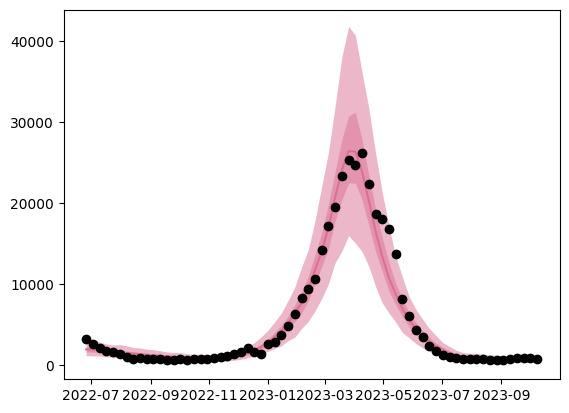

In [9]:
# Sample trajectories from the model case beams
# =============================================
sim_config_dict

d = sim_config_dict["observation_model"]
if d["model"] != "negative_binomial":
    raise NotImplementedError("Only negative binomial observation model is supported.")

rng = np.random.default_rng(seed=42)

# --- Re-sample from the posterior to choose trajectories to sample from
num_trajectories = 1000
re_sample_params: pd.DataFrame = posterior_samples_df.sample(
    n=num_trajectories,
    replace=True,
    weights=posterior_samples_df["posterior_weight"],
    random_state=rng,
)

re_sample_mean_cases = mean_cases_df.reindex(re_sample_params.index)

# After identifying original simulations, reset the indexes to sequential
for obj in [re_sample_params, re_sample_mean_cases]:
    obj.reset_index(drop=True, inplace=True)
    obj.index.name = "i_sample"

# --- Reshape to 2D arrays and sample everything at once
# Standard shape: (i_sample, i_time)
_expectancy = re_sample_mean_cases.values
_overdisp = re_sample_params["notif_nb_overdispersion"].to_numpy()[:, np.newaxis]
p = _overdisp / (_overdisp + _expectancy)

cases_vec: np.ndarray = rng.negative_binomial(
    n=_overdisp, p=p, size=_expectancy.shape
)
cases_df = pd.DataFrame(
    cases_vec,
    index=re_sample_params.index,
    columns=re_sample_mean_cases.columns
)

cases_df

# --- Visualize sampled trajectories
fig, ax = plt.subplots()

with mpl.rc_context(
        {
            "patch.linewidth": 0,
        }
):
    # === Model trajectories
    ax.fill_between(
        cases_df.columns,
        cases_df.quantile(0.025), cases_df.quantile(0.975),
        color="palevioletred", alpha=0.5, label="95% CI"
    )
    ax.fill_between(
        cases_df.columns,
        cases_df.quantile(0.25), cases_df.quantile(0.75),
        color="palevioletred", alpha=0.5, label="50% CI"
    )

    ax.plot(cases_df.median(), label="Median", color="palevioletred")

    # === Observations
    sr = observations_sr[cases_df.columns]
    ax.plot(sr, label="Observations", color="black", marker="o", linestyle="")

    fig

## Outbreak features from trajectories
- Feats
    - case_attack_rate
    - peak_date
    - peak_amplitude
- Consider only the IMDC window (currenrlt same as calibration window)

,case_attack_rate,peak_week,peak_amplitude
i_sample,,,
0,335136,26.0,34335
1,343202,24.0,34557
2,318801,26.0,30760
3,300335,23.0,25286
4,328009,25.0,45774
...,...,...,...
995,341509,25.0,40740
996,354907,27.0,30920
997,309590,27.0,26003


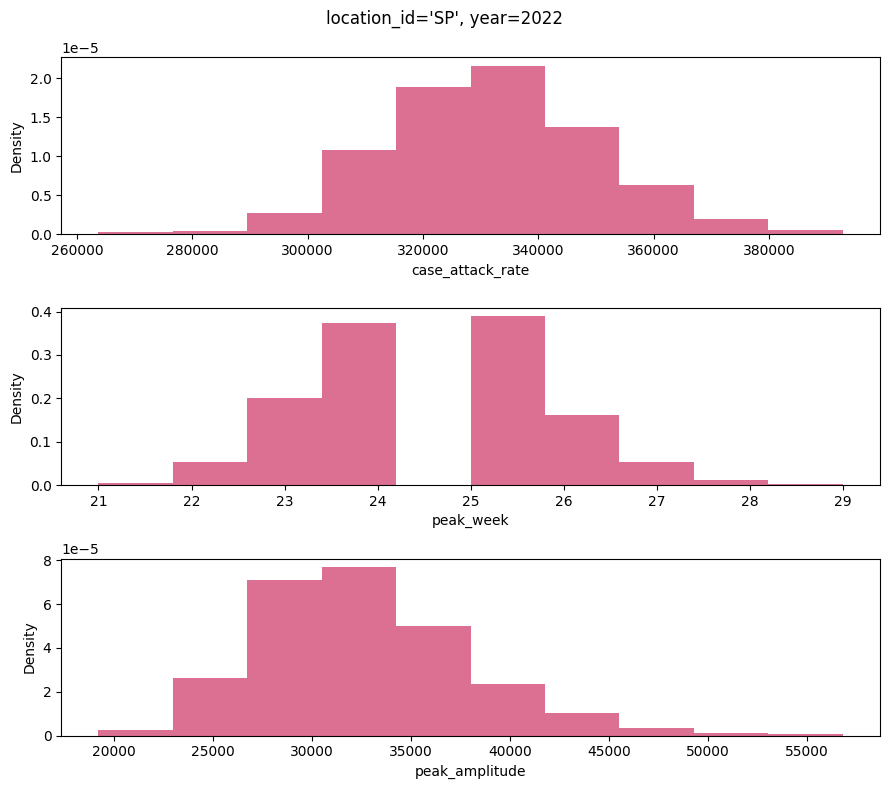

In [10]:
# --- Crop calculation window
d = sim_config_dict

# # -()-
# window_start = pd.Timestamp(d["temporal"]["calibration_start"])
# window_end = pd.Timestamp(d["temporal"]["calibration_end"])
# -()-
window_start = year_week_to_date(year, projections_start_epiweek)
window_end = year_week_to_date(year + 1, projections_end_epiweek)

df = cases_df.loc[:, window_start:window_end]
obs = observations_sr.loc[window_start:window_end]  # If observations

# Etc params
date_zero = pd.Timestamp(d["temporal"]["zero_date"])

# ====
features = pd.DataFrame(index=df.index)

features["case_attack_rate"] = df.sum(axis=1)
features["peak_week"] = (df.idxmax(axis=1) - date_zero).dt.days / 7
features["peak_amplitude"] = df.max(axis=1)


# ================

with plt.rc_context({

}):
    feat_names = features.columns.to_list()
    fig, axes = plt.subplots(
        nrows=len(feat_names),
        ncols=1,
        figsize=(3*len(feat_names), 8)
    )

    for i_feat, feat_name in enumerate(feat_names):
        ax: plt.Axes = axes[i_feat]
        feat_vals = features[feat_name]

        # --- Histogram
        ax.hist(
            feat_vals,
            density=True,
            color="palevioletred",
        )

        ax.set_xlabel(feat_name)
        ax.set_ylabel("Density")

    fig.suptitle(f"{location_id=}, {year=}")
    fig.tight_layout()

    fig.savefig(
        out_dir / "outbreak_feature_estimates.pdf",
    )

features




# Alternative: Calculate feature distributions for each parameter set
By sampling a few stochastic trajectories from each.
More computationally intensive, but will allow us to compare with the outbreak feature predictions from the stats/ML component.

In [3]:
# Augment samples by adding a stochastic dimension for each parameter set
# ===========
n_stochastic = 100  # Number of stochastic trajectories from each parameter set

# ----

df = mean_cases_df
i_sim_var = "i_simulation"  # Must be the simulation id index in all data frames
augm_index = pd.MultiIndex.from_product(
    [df.index, range(n_stochastic)], names=[i_sim_var, "i_stochastic"]
)
#   ^ ^ New index signature: (i_simulations, i_stochastic)
i_sim_index = augm_index.get_level_values(i_sim_var)

# Augment the time series of new cases
augm_mean_cases_df = df.reindex(i_sim_index)
augm_mean_cases_df.index = augm_index

# Augment the posterior samples (parameter sets)
augm_posterior_samples_df = posterior_samples_df.reindex(i_sim_index)
augm_posterior_samples_df.index = augm_index


# Apply the 2D reshaping to sample trajectories with vectorized numpy
# =======================
# Standard shape: (i_augmented_sample, i_time)
_expectancy = augm_mean_cases_df.values
_overdisp = augm_posterior_samples_df["notif_nb_overdispersion"].to_numpy()[:, np.newaxis]
p = _overdisp / (_overdisp + _expectancy)

# Sample with negative binomial (observation model)
rng = np.random.default_rng(seed=42)
cases_vec: np.ndarray = rng.negative_binomial(
    n=_overdisp, p=p, size=_expectancy.shape
)
cases_df = pd.DataFrame(
    cases_vec,
    index=augm_mean_cases_df.index,
    columns=augm_mean_cases_df.columns
)

cases_df




# augm_posterior_samples_df

2022-06-26  2022-07-03  2022-07-10  2022-07-17  \
i_simulation i_stochastic                                                   
222906       0                   2119        1448        1870        1763   
             1                   1741        2445        2223        1676   
             2                   1950        1606        1886        2006   
             3                   1836        2246        1973        1523   
             4                   1748        1984        2410        1686   
...                               ...         ...         ...         ...   
258552       95                  1916        1739        2537        1663   
             96                  2220        1636        1986        1579   
             97                  1975        1430        2000        1318   
             98                  1754        2219        2589        2118   
             99                  2756        1346        1516        1533   

                           2022-07-24  2022-07-31  2022-08-07  2022-08-14  \
i_simulation i_stochastic                                                   
222906       0                   1814        1584        1591        1948   
             1                   2075        1670        1941        1392   
             2                   1291        1659        1481        1590   
             3                   1454        1361        1686        1457   
             4                   1941        1660        1558        1155   
...                               ...         ...         ...         ...   
258552       95                  1666        2285        1911        1423   
             96                  1668        2619        1356        1910   
             97                  1426        1241        1609        1502   
             98                  1052         988        1807        1998   
             99                  1913        1498        1391        1720   

                           2022-08-21  2022-08-28  ...  2023-08-06  \
i_simulation i_stochastic                          ...               
222906       0                   1446        1122  ...        1289   
             1                   1469        1718  ...        1021   
             2                   1437        1203  ...         908   
             3                   1339        1499  ...         719   
             4                   1194        1216  ...         692   
...                               ...         ...  ...         ...   
258552       95                   989        1033  ...         879   
             96                  1464        1358  ...         562   
             97                  1283        1068  ...        1087   
             98                  1429        1117  ...         783   
             99                  1515         917  ...         861   

                           2023-08-13  2023-08-20  2023-08-27  2023-09-03  \
i_simulation i_stochastic                                                   
222906       0                    862         696         622         683   
             1                   1015        1009         981         750   
             2                    853         739         795         638   
             3                    834         957         855         594   
             4                    978         774         984         600   
...                               ...         ...         ...         ...   
258552       95                  1047         756         986        1152   
             96                  1101         876         712         650   
             97                   839         888         938         652   
             98                   967         911        1259        1070   
             99                   704         666         910         940   

                           2023-09-10  2023-09-17  2023-09-24  2023-10-01  \
i_simulation i_stochastic        

In [13]:
# Calculate outbreak features for each parameter set
# ============
# --- Crop calculation window
d = sim_config_dict

# # -()-
# window_start = pd.Timestamp(d["temporal"]["calibration_start"])
# window_end = pd.Timestamp(d["temporal"]["calibration_end"])
# -()-
window_start = year_week_to_date(year, projections_start_epiweek)
window_end = year_week_to_date(year + 1, projections_end_epiweek)

date_zero = pd.Timestamp(d["temporal"]["zero_date"])

# ---
df = cases_df.loc[:, window_start:window_end]
obs = observations_sr.loc[window_start:window_end]  # If observations

features_df = pd.DataFrame(index=df.index)

features_df["case_attack_rate"] = df.sum(axis=1)
features_df["peak_week"] = (df.idxmax(axis=1) - date_zero).dt.days / 7
features_df["peak_amplitude"] = df.max(axis=1)

features_df
# Signature: df.loc[(i_simulation, i_stochastic), feature]
# Still holds the outbreak features of each stochastic realization

# -()- Just the mean
# features_df.groupby("i_simulation").agg(
#     case_attack_rate=("case_attack_rate", "mean"),
#     peak_week=("peak_week", "mean"),
#     peak_amplitude=("peak_amplitude", "mean"),
# )

# -()- Multiple statistics
agg_funcs = {
    col: [
        ("mean", "mean"),
        ("std", "std"),
        ("q025", lambda x: x.quantile(0.025)),
        ("q975", lambda x: x.quantile(0.975)),
    ]
    for col in features_df.columns
}

feature_dists_df = features_df.groupby("i_simulation", sort=False).agg(agg_funcs)

feature_dists_df


case_attack_rate                                         \
                         mean            std        q025        q975   
i_simulation                                                           
222906              339696.28   12023.240684  320029.575  364596.525   
155106              334510.44   11663.033571  307444.100  355249.925   
11473               323534.92   10606.370375  304623.575  344536.250   
40262               305641.23   96036.675826  155169.025  529881.000   
145988              333159.18  107737.907165  174583.650  598496.225   
...                       ...            ...         ...         ...   
196454              338807.23   16334.640058  306253.475  367834.650   
259698              337091.64   16361.724054  310585.975  368826.325   
100900              337613.63   14706.745276  310594.200  362773.225   
97937               329676.34   20738.188895  291185.075  369786.600   
258552              339173.87   17658.818812  308563.150  382110.275   

             peak_week                           peak_amplitude                \
                  mean       std    q025    q975           mean           std   
i_simulation                                                                    
222906           24.13  1.011599  22.000  26.000       31265.90   3069.768022   
155106           24.36  1.077970  22.475  26.000       30787.25   3152.857214   
11473            24.34  1.084510  22.000  26.000       29385.51   3229.087795   
40262            24.90  3.397860  17.950  31.000       75198.79  40712.558131   
145988           23.95  3.195246  18.000  30.000       86526.38  50097.769420   
...                ...       ...     ...     ...            ...           ...   
196454           24.49  1.234970  22.000  27.000       33762.76   4501.949838   
259698           24.30  1.337116  22.000  27.000       33568.53   4774.706188   
100900           24.47  1.351804  22.000  27.000       33331.76   5421.449421   
97937            24.33  1.318516  22.000  27.000       32597.08   5291.179935   
258552           24.61  1.109145  23.000  26.525       33359.40   5214.380289   

                                     
                   q025        q975  
i_simulation                         
222906        26181.700   37077.825  
155106        24914.925   36804.875  
11473         24375.250   36792.325  
40262         22458.425  191761.425  
145988        26486.150  228146.350  
...                 ...         ...  
196454        25365.900   43580.300  
259698        25425.200   43581.500  
100900        24830.375   43985.100  
97937         22718.500   43992.325  
258552        25378.425   41731.325  

[3707 rows x 12 columns]

In [18]:
df = feature_dists_df

# # df[("case_attack_rate", "mean")].hist(density=True, color="palevioletred", weights=posterior_samples_df["posterior_weight"])
# df[("case_attack_rate", "std")].hist(density=True, color="palevioletred", weights=posterior_samples_df["posterior_weight"])


In [18]:
# # # Print config dict
import yaml

s = io.StringIO()
yaml.dump(d, s)

print(s.getvalue())

gt_max: 49
initial_infections: !!python/object:inframind_proteus.outbreak_dynamics.initial_infections.InitialInfectionsConfig
  method: ones
  num_steps: 7
  params: {}
location:
  location_id: SP
  location_id_variable: uf
  population_size: 45736978
mode: calibration
num_simulations: 262144
num_time_steps: 68
observation_model:
  model: negative_binomial
  params:
    notif_nb_overdispersion: 150.0
    notif_relative_scale: 5.09825745194647
    notif_scaling_factor: 250.0
  reference_population_size: 100000
output:
  keep_rt_trajectories: true
  main_dir: outputs/prototype_run_dynamic_model
rng_seed: 123
sampling: !!python/object:inframind_proteus.outbreak_dynamics.sampling.SamplingConfig
  method: sobol
  observation_params:
    notif_nb_overdispersion: 150.0
    notif_relative_scale: 5.09825745194647
    notif_scaling_factor: 250.0
  param_priors: {}
  param_ranges: {}
  param_scales:
    notif_nb_overdispersion: inverse
  rng_seed: 123
  rt_params:
    rt_logist_dt_center: 129.213